# Run model

## Imports

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, classification_report, accuracy_score


## Data

In [12]:
directory = 'clean_features'
data = {}
for filename in os.listdir(directory):
    
    if filename.endswith('.csv') and filename.startswith('clean_output'):
        # Extract the number from the filename
        user_number = filename.split('output')[1].split('.')[0]
        user_key = f'User_{user_number}'

        # Load the CSV into a DataFrame
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path, index_col=False)

        # Add to the dictionary
        data[user_key] = df

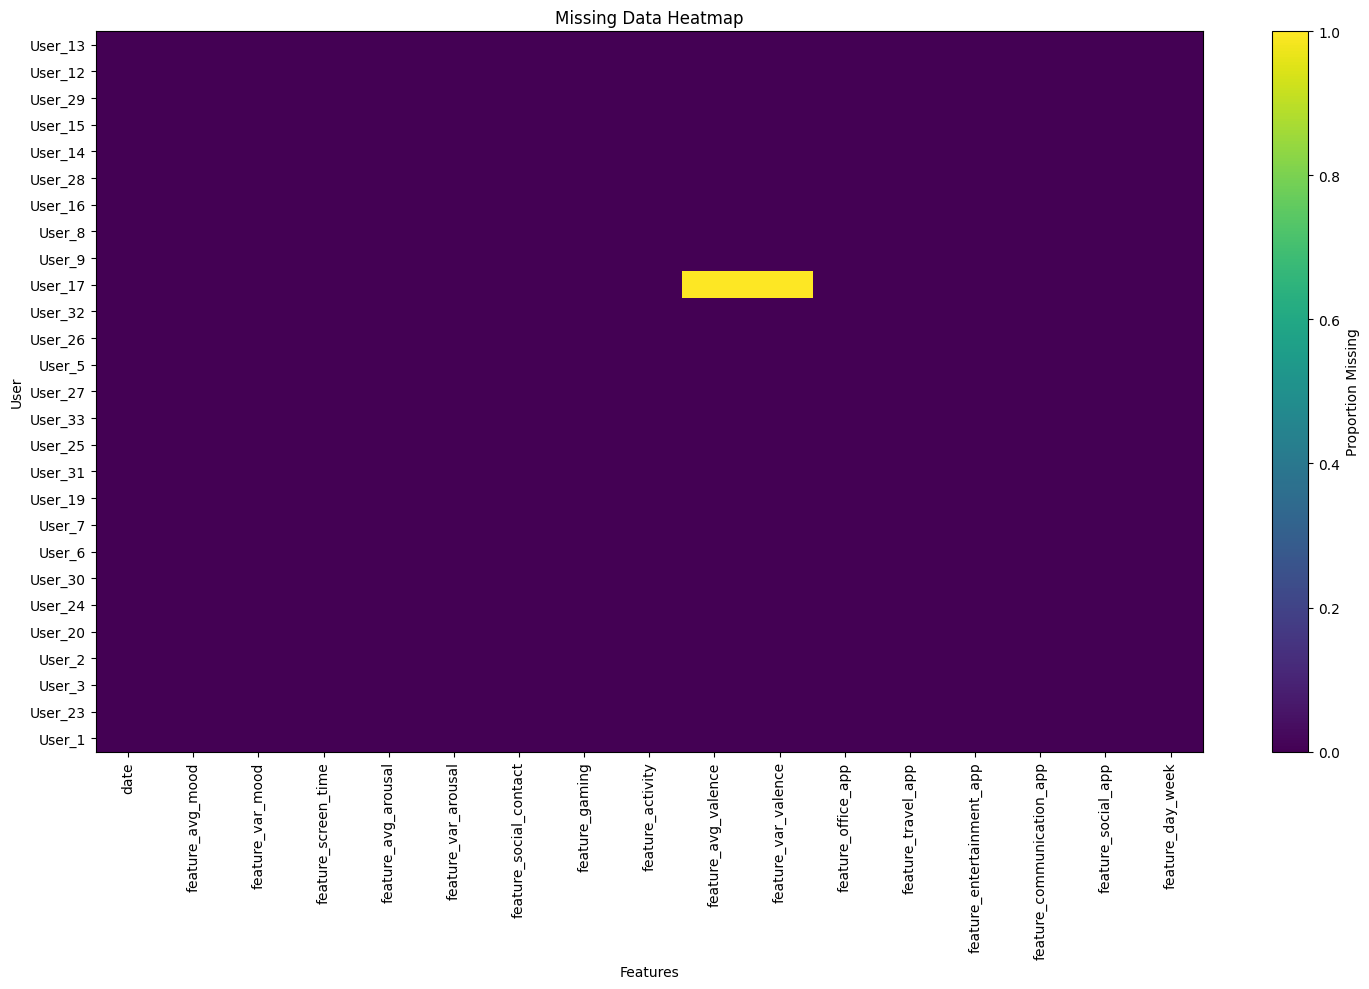

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume your dictionary is called `data`
missing_data = {}

for user, df in data.items():
    missing_per_feature = df.isna().sum()
    missing_data[user] = missing_per_feature

# Create a DataFrame: rows = users, columns = features
missing_df = pd.DataFrame(missing_data).T  # users as rows

# Optional: Normalize to [0, 1] range (proportion missing)
missing_normalized = missing_df / missing_df.max().max()

# Create the heatmap
fig, ax = plt.subplots(figsize=(15, 10))
cax = ax.imshow(missing_normalized, aspect='auto', cmap='viridis')

# Set axis labels
ax.set_xticks(np.arange(len(missing_normalized.columns)))
ax.set_xticklabels(missing_normalized.columns, rotation=90)

ax.set_yticks(np.arange(len(missing_normalized.index)))
ax.set_yticklabels(missing_normalized.index)

ax.set_xlabel("Features")
ax.set_ylabel("User")
ax.set_title("Missing Data Heatmap")

# Add colorbar
fig.colorbar(cax, ax=ax, label='Proportion Missing')

plt.tight_layout()
plt.show()

## Random forest

In [16]:
from sklearn.model_selection import train_test_split

# --- 1. Prepare data: Feature matrix X and target vector y ---
X_all, y_all = [], []

for user, df in data.items():
    df = df.sort_values('date')

    # Target: Next day's mood
    df['target'] = df['feature_avg_mood'].shift(-1)
    df = df[df['target'].notna()]

    X_all.append(df.drop(columns=['date', 'target', 'feature_avg_mood']))
    y_all.append(df['target'])

X = pd.concat(X_all, ignore_index=True)
y = pd.concat(y_all, ignore_index=True)

print(f"✅ Data loaded: {X.shape[0]} samples, {X.shape[1]} features")

# --- 1b. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"🧪 Train/Test split: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")

# --- 2. Initialize model and cross-validation setup ---
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("🌲 Random Forest Regressor initialized with 1000 trees")

# --- 3. Evaluate using cross-validation (R² score) on **training set** ---
r2_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')

print("\n📈 Cross-Validation Results (5-fold on train set):")
for i, score in enumerate(r2_scores, 1):
    print(f"  - Fold {i} R² Score: {score:.4f}")
print(f"  - Mean R² Score: {np.mean(r2_scores):.4f}")
print(f"  - Std Dev of R² Scores: {np.std(r2_scores):.4f}")

# --- 4. Fit model to training set ---
rf.fit(X_train, y_train)
print("\n✅ Model trained on training set")

# --- 5. Feature importance ranking ---
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print("\n🏆 Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# --- 6. Evaluate final model on test set ---
y_pred = rf.predict(X_test)

final_r2 = r2_score(y_test, y_pred)
final_mae = mean_absolute_error(y_test, y_pred)

print("\n🧪 Final Evaluation on Test Set:")
print(f"  - R² Score: {final_r2:.4f}")
print(f"  - Mean Absolute Error (MAE): {final_mae:.4f}")

✅ Data loaded: 1214 samples, 15 features
🧪 Train/Test split: 971 train samples, 243 test samples
🌲 Random Forest Regressor initialized with 1000 trees

📈 Cross-Validation Results (5-fold on train set):
  - Fold 1 R² Score: 0.8741
  - Fold 2 R² Score: 0.8090
  - Fold 3 R² Score: 0.8172
  - Fold 4 R² Score: 0.8784
  - Fold 5 R² Score: 0.8258
  - Mean R² Score: 0.8409
  - Std Dev of R² Scores: 0.0294

✅ Model trained on training set

🏆 Top 10 Most Important Features:
                  Feature  Importance
      feature_avg_valence    0.230746
      feature_var_arousal    0.145716
feature_entertainment_app    0.116388
      feature_avg_arousal    0.108687
         feature_var_mood    0.105588
       feature_office_app    0.083311
      feature_var_valence    0.055119
   feature_social_contact    0.034850
       feature_social_app    0.027069
         feature_activity    0.022738

🧪 Final Evaluation on Test Set:
  - R² Score: 0.8925
  - Mean Absolute Error (MAE): 0.0655


## Random Forest Classifier

In [15]:
# --- 1. Combine all user data into feature matrix X and target vector y ---
X_all, y_all = [], []

for user, df in data.items():
    df = df.sort_values('date')
    
    
    df = df[df['feature_avg_mood'].notna()]
    # Target: Next day's mood
    df['target'] = df['feature_avg_mood'].shift(-1)
    df = df[df['target'].notna()]

    X_all.append(df.drop(columns=['date', 'target', 'feature_avg_mood']))
    
    # Apply dynamic binning to mood scores
    # Assign class labels based on mood range: 0-2, 2-4, 4-6, 6-8, 8-10
    def encode_targets(y, n_bins):
        bin_edges = np.percentile(y, np.linspace(0, 100, n_bins))
        binned_y = np.digitize(y, bin_edges, right=True)
        return binned_y
    
    n_bins = 5
    y = encode_targets(df['target'], n_bins)    
    y_all.append(pd.Series(y, index=df.index))  # ✅ Append binned values

X = pd.concat(X_all, ignore_index=True)
y = pd.concat(y_all, ignore_index=True)

print(f"✅ Data prepared: {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Split data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"📊 Train/Test split: {X_train.shape[0]} train / {X_test.shape[0]} test samples")

# --- 3. Initialize the Random Forest classifier ---
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)
print("🌲 Random Forest initialized with 1000 trees")

# --- 4. Evaluate model using 5-fold cross-validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')

print("\n📈 Cross-validation results (Training data):")
print("  - Fold-wise Accuracy:", np.round(accuracy_scores, 4))
print("  - Mean Accuracy: {:.4f}".format(np.mean(accuracy_scores)))
print("  - Std Deviation: {:.4f}".format(np.std(accuracy_scores)))

# --- 5. Fit the model on the full training set ---
rf.fit(X_train, y_train)
print("✅ Model trained on full training data")

# --- 6. Predict on test data ---
y_pred = rf.predict(X_test)

# --- 7. Evaluate predictions ---
test_accuracy = accuracy_score(y_test, y_pred)
print("\n🧪 Evaluation on Test Data:")
print(f"  - Accuracy: {test_accuracy:.4f}")

print("\n📄 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# --- 8. Feature importances ---
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n🏆 Top Features by Importance:")
print(importance_df.head(10).to_string(index=False))

✅ Data prepared: 1214 samples, 15 features
📊 Train/Test split: 971 train / 243 test samples
🌲 Random Forest initialized with 1000 trees

📈 Cross-validation results (Training data):
  - Fold-wise Accuracy: [0.6308 0.6443 0.6701 0.5928 0.6186]
  - Mean Accuracy: 0.6313
  - Std Deviation: 0.0258
✅ Model trained on full training data

🧪 Evaluation on Test Data:
  - Accuracy: 0.6255

📄 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.68      0.83      0.75        52
           2       0.62      0.54      0.58        67
           3       0.58      0.48      0.53        62
           4       0.62      0.74      0.68        58

    accuracy                           0.63       243
   macro avg       0.50      0.52      0.51       243
weighted avg       0.61      0.63      0.61       243


🏆 Top Features by Importance:
                  Feature  Importance
         feature_activity 